# Units 2 + 3 Practice — Working Notebook

**Combined corridor task:** map-match one Tel Aviv corridor (U2 skill) → slice it into segments → forecast each segment's *breakeven horizon* (U3 skill).

Open-ended — no answer key. The deliverable is the decision log.

**Corridor:** Yigal Alon St, Yitzhak Sade → Emek Bracha, spine line 2276. **Segmentation:** junction-to-junction (10 blocks). **Cadence:** hourly (bus GPS too sparse for 15-min).

---
## Part 1 — See the raw bus data on a map

In [1]:
# Setup + config
import pandas as pd, numpy as np
import folium
from folium.plugins import HeatMap
from pyproj import Transformer
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
import json, os

DATA = "tlv_all.parquet"
CENTER = [32.075, 34.81]
HEATMAP_SAMPLE = 150_000
SAT_TILES = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
_tf  = Transformer.from_crs("EPSG:4326", "EPSG:2039", always_xy=True)
_inv = Transformer.from_crs("EPSG:2039", "EPSG:4326", always_xy=True)
print("config ready")

config ready


In [2]:
df = pd.read_parquet(DATA)
df['line_ref'] = df['line_ref'].astype(str)
print("rows (pings):", f"{len(df):,}", "| lines:", df['line_ref'].nunique(), "| vehicles:", df['vehicle_ref'].nunique())
df.head(3)

rows (pings): 4,725,997 | lines: 1458 | vehicles: 6612


,recorded_at_time,lon,lat,bearing,velocity,line_ref,vehicle_ref
0,2023-02-01 00:00:02+00:00,34.779526,32.098839,82,0,7022,7659169
1,2023-02-01 00:00:20+00:00,34.834183,32.079205,10,29,15035,7693069
2,2023-02-01 00:00:28+00:00,34.814762,32.079338,84,0,2510,9297001


In [3]:
samp = df[['lat', 'lon']].dropna().sample(n=min(HEATMAP_SAMPLE, len(df)), random_state=42)
m = folium.Map(location=CENTER, zoom_start=12, tiles=None, control_scale=True)
folium.TileLayer("OpenStreetMap", name="Street (OSM)").add_to(m)
folium.TileLayer("CartoDB positron", name="Light").add_to(m)
folium.TileLayer("CartoDB dark_matter", name="Dark").add_to(m)
folium.TileLayer(tiles=SAT_TILES, attr="Tiles © Esri", name="Satellite").add_to(m)
HeatMap(samp.values.tolist(), radius=6, blur=4, min_opacity=0.3, name=f"density ({len(samp):,})").add_to(m)
folium.LayerControl(collapsed=False).add_to(m); m.save("map_all_pings.html"); print("saved -> map_all_pings.html")

saved -> map_all_pings.html


---
## Part 2 — Which road? (spine-line check)
Menachem Begin (west) vs Yigal Alon (east). Busiest lines run **Yigal Alon** — our corridor.

In [4]:
BOX = dict(lat=(32.064, 32.088), lon=(34.786, 34.797))
box = df[df.lat.between(*BOX['lat']) & df.lon.between(*BOX['lon'])]; mid_lon = np.mean(BOX['lon'])
for lid in ['2294','9788','2276']:
    g = box[box.line_ref == lid]
    print(f"  line {lid}: {len(g):>5} dots | med_lon {g.lon.median():.4f} | {'Begin' if g.lon.median()<mid_lon else 'Yigal Alon'}")

  line 2294:  2959 dots | med_lon 34.7887 | Begin
  line 9788:  3045 dots | med_lon 34.7885 | Begin
  line 2276:  4551 dots | med_lon 34.7926 | Yigal Alon


---
## Part 3 — Corridor centerline + snapping (U2 shape recovery)
`snap_to_centerline()` = proper map-matching: returns arc-length along the road + distance to the road.

In [5]:
TARGET_ROAD="Yigal Alon St"; SPINE_LINE="2276"
END_S=(34.7923,32.0642); END_N=(34.7966,32.0769)
SX,SY=_tf.transform(*END_S); _NX,_NY=_tf.transform(*END_N)
_A=np.array([_NX-SX,_NY-SY]); L=float(np.hypot(*_A)); U=_A/L
def _along_lateral(lon,lat):
    px,py=_tf.transform(np.asarray(lon),np.asarray(lat)); dx,dy=px-SX,py-SY
    return dx*U[0]+dy*U[1], -dx*U[1]+dy*U[0]
def build_centerline(spine,n_bins=60,lat_max=150,min_per_bin=5):
    along,lat=_along_lateral(spine[:,0],spine[:,1]); x,y=_tf.transform(spine[:,0],spine[:,1])
    keep=(along>=-30)&(along<=L+30)&(np.abs(lat)<=lat_max); bins=np.linspace(0,L,n_bins+1); wc=np.digitize(along[keep],bins)
    xk,yk=x[keep],y[keep]
    return np.array([(np.median(xk[wc==b]),np.median(yk[wc==b])) for b in range(1,n_bins+1) if (wc==b).sum()>=min_per_bin])
cl_xy=build_centerline(df[df.line_ref==SPINE_LINE][['lon','lat']].dropna().values)
_CV=cl_xy[1:]-cl_xy[:-1]; _CL2=(_CV**2).sum(1); cl_s=np.concatenate([[0],np.cumsum(np.hypot(_CV[:,0],_CV[:,1]))]); CORRIDOR_LEN=float(cl_s[-1])
def snap_to_centerline(lon,lat):
    px,py=_tf.transform(np.asarray(lon,float),np.asarray(lat,float)); px,py=np.atleast_1d(px),np.atleast_1d(py)
    bd,ba=np.full(px.shape,np.inf),np.zeros(px.shape)
    for k in range(len(_CV)):
        if _CL2[k]==0: continue
        t=np.clip(((px-cl_xy[k,0])*_CV[k,0]+(py-cl_xy[k,1])*_CV[k,1])/_CL2[k],0,1)
        d=np.hypot(px-(cl_xy[k,0]+t*_CV[k,0]),py-(cl_xy[k,1]+t*_CV[k,1])); u=d<bd; bd[u]=d[u]; ba[u]=cl_s[k]+t[u]*np.sqrt(_CL2[k])
    return ba,bd
cl_lon,cl_lat=_inv.transform(cl_xy[:,0],cl_xy[:,1]); cl_latlon=list(zip(cl_lat,cl_lon))
print(f"{TARGET_ROAD} | centerline {len(cl_xy)} pts, {CORRIDOR_LEN:.0f} m")

Yigal Alon St | centerline 57 pts, 1428 m


---
## Part 4 — Cut junction-to-junction
Curated junctions (Overpass named-cross-streets, then hand-curated: dropped Navon bridge, merged HaShalom & Nachalat-Yitzhak clusters, excluded Kremenetski).

In [6]:
CURATED_JUNCTIONS=[("Yitzhak Sade",34.79229,32.06437),("Aminadav",34.79243,32.06508),("Dalia Ravikovitch",34.79318,32.06817),
  ("Vicki Shiran",34.79357,32.06938),("Shlomo Kaplan",34.79375,32.06975),("Tuval",34.79390,32.07040),("HaOmanim",34.79442,32.07165),
  ("HaShalom",34.79466,32.07245),("Totzeret HaAretz",34.79516,32.07366),("Nachalat Yitzhak",34.79578,32.07534),("Emek Bracha",34.79645,32.07688)]
_ja,_=snap_to_centerline([j[1] for j in CURATED_JUNCTIONS],[j[2] for j in CURATED_JUNCTIONS])
junctions=sorted([[float(_ja[i]),CURATED_JUNCTIONS[i][2],CURATED_JUNCTIONS[i][1],CURATED_JUNCTIONS[i][0]] for i in range(len(CURATED_JUNCTIONS))])
edges=np.array([j[0] for j in junctions])
segments=[dict(id=i,name=f"{junctions[i][3]} → {junctions[i+1][3]}",a0=junctions[i][0],a1=junctions[i+1][0],length=junctions[i+1][0]-junctions[i][0]) for i in range(len(junctions)-1)]
print(f"{len(junctions)} junctions -> {len(segments)} segments")
for s in segments: print(f"  {s['id']:>2}  {s['name']:34s}  {s['length']:>5.0f} m")
PALETTE=['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628']
m4=folium.Map(location=[(END_N[1]+END_S[1])/2,(END_N[0]+END_S[0])/2],zoom_start=15,tiles="OpenStreetMap",control_scale=True)
for s in segments:
    mask=(cl_s>=s['a0']-1)&(cl_s<=s['a1']+1)
    pts=[[junctions[s['id']][1],junctions[s['id']][2]]]+[[la,lo] for la,lo in zip(cl_lat[mask],cl_lon[mask])]+[[junctions[s['id']+1][1],junctions[s['id']+1][2]]]
    folium.PolyLine(pts,color=PALETTE[s['id']%len(PALETTE)],weight=6,opacity=0.9,tooltip=f"seg {s['id']}: {s['name']}").add_to(m4)
for a,lat,lon,name in junctions:
    folium.CircleMarker([lat,lon],radius=4,color="black",fill=True,fill_color="white",fill_opacity=1,weight=2,tooltip=f"{name} @ {a:.0f} m").add_to(m4)
m4.save("map_segments.html"); print("saved -> map_segments.html")

11 junctions -> 10 segments
   0  Yitzhak Sade → Aminadav                50 m
   1  Aminadav → Dalia Ravikovitch          352 m
   2  Dalia Ravikovitch → Vicki Shiran      143 m
   3  Vicki Shiran → Shlomo Kaplan           46 m
   4  Shlomo Kaplan → Tuval                  72 m
   5  Tuval → HaOmanim                      147 m
   6  HaOmanim → HaShalom                    94 m
   7  HaShalom → Totzeret HaAretz           143 m
   8  Totzeret HaAretz → Nachalat Yitzhak    198 m
   9  Nachalat Yitzhak → Emek Bracha        182 m
saved -> map_segments.html


---
## Part 5 — Map-match all dots → per-block speed samples
Snap all lines' dots (±25 m ribbon), consecutive same-vehicle pairs → speed (dist÷Δt), assigned to midpoint's block. Knobs: ribbon ±25 m, Δt 30–120 s, ceiling 80 km/h, dwell kept, pool all lines.

In [7]:
RIBBON_M,DT_MIN,DT_MAX,SPEED_CEIL=25,30,120,80
CORRIDOR_BBOX=dict(lat=(32.062,32.079),lon=(34.789,34.800))
sub=df[df.lat.between(*CORRIDOR_BBOX['lat'])&df.lon.between(*CORRIDOR_BBOX['lon'])].copy()
sub['along'],sub['dist']=snap_to_centerline(sub.lon.values,sub.lat.values)
onc=sub[(sub.dist<=RIBBON_M)&(sub.along.between(0,CORRIDOR_LEN))].copy()
onc['seg']=np.clip(np.digitize(onc['along'],edges)-1,0,len(segments)-1)
onc['t']=pd.to_datetime(onc.recorded_at_time).dt.tz_convert('Asia/Jerusalem')
onc['x'],onc['y']=_tf.transform(onc.lon.values,onc.lat.values)
onc=onc.sort_values(['vehicle_ref','t']); g=onc.groupby('vehicle_ref',sort=False)
dt=g['t'].diff().dt.total_seconds(); dstep=np.hypot(g['x'].diff(),g['y'].diff()); spd=dstep/dt*3.6; mid=(onc['along']+g['along'].shift())/2
good=(dt>=DT_MIN)&(dt<=DT_MAX)&(spd<=SPEED_CEIL)
pairs=pd.DataFrame({'seg':np.clip(np.digitize(mid,edges)-1,0,len(segments)-1),'t':onc['t'],'speed':spd,'line':onc['line_ref']})[good.values].dropna()
pairs['seg']=pairs['seg'].astype(int)
print(f"on-corridor pings {len(onc):,} | valid speed samples {len(pairs):,}")
dens=pd.DataFrame([(s['id'],s['name'],s['length'],len(pairs[pairs.seg==s['id']]),pairs[pairs.seg==s['id']].speed.median()) for s in segments],
                  columns=['seg','block','len_m','samples','median_kmh'])
print(dens.to_string(index=False,float_format=lambda v:f"{v:.1f}"))

on-corridor pings 16,345 | valid speed samples 5,754
 seg                               block  len_m  samples  median_kmh
   0             Yitzhak Sade → Aminadav   50.2      111         4.9
   1        Aminadav → Dalia Ravikovitch  351.6     1742        15.6
   2    Dalia Ravikovitch → Vicki Shiran  142.9      502        19.1
   3        Vicki Shiran → Shlomo Kaplan   46.3      419        11.4
   4               Shlomo Kaplan → Tuval   72.3      347        13.9
   5                    Tuval → HaOmanim  146.9      702        11.3
   6                 HaOmanim → HaShalom   93.9      410         8.3
   7         HaShalom → Totzeret HaAretz  143.4      557         8.0
   8 Totzeret HaAretz → Nachalat Yitzhak  198.4      575        12.4
   9      Nachalat Yitzhak → Emek Bracha  182.3      389         7.7


---
## Part 6 — Hourly speed series + stationarity (U3 setup)

Each block's samples → **hourly** series (mean, ≥3 passes/bin), reindexed to a full hourly grid with short gaps **time-interpolated** (logged empty-bin rule). **seg 0 dropped** — 0 usable bins, data-limited. Weekends = Fri/Sat (shaded). ADF tests stationarity in level; the daily cycle it can't see is SARIMA's job next.

seg1 (Aminadav → Dalia Ravikovitch): 240 usable bins / 381 grid (63%) | mean 16.5 km/h | ADF p=9.1e-08 -> stationary
seg7 (HaShalom → Totzeret HaAretz): 87 usable bins / 376 grid (23%) | mean 8.6 km/h | ADF p=9.7e-05 -> stationary


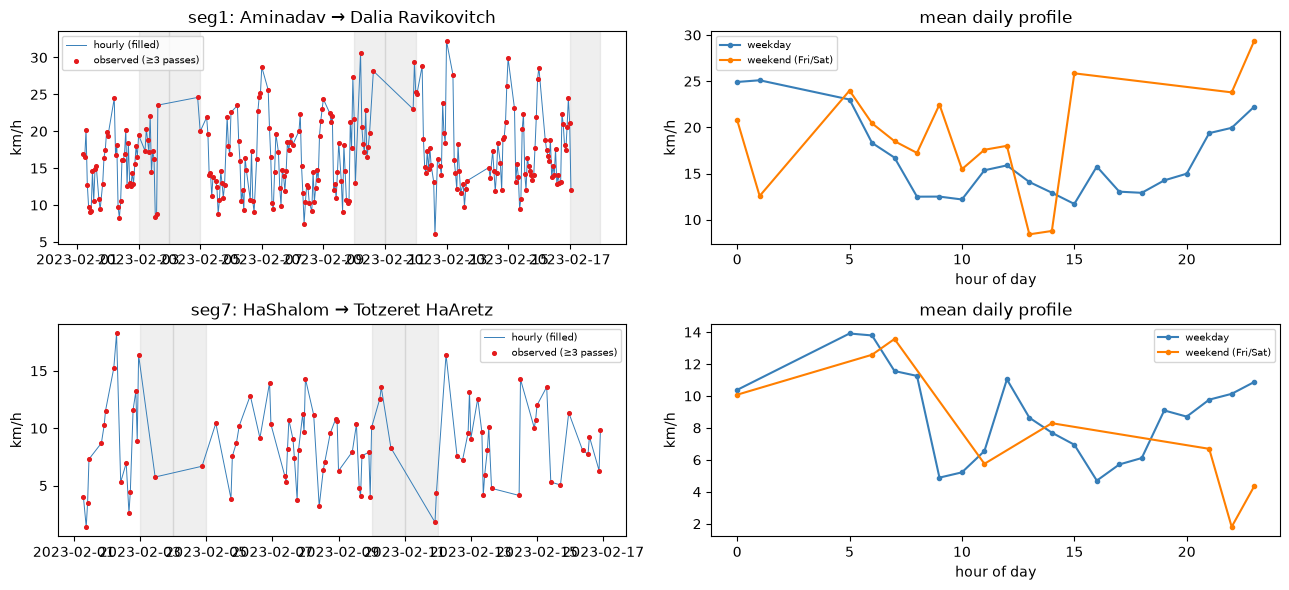

In [8]:
from statsmodels.tsa.stattools import adfuller
BIN="60min"; MIN_PASSES=3; FORECAST_SEGS=[1,7]

def hourly_series(sid, min_passes=MIN_PASSES):
    p=pairs[pairs.seg==sid].set_index('t')['speed'].sort_index()
    grp=p.resample(BIN); raw=grp.mean()[grp.count()>=min_passes]
    grid=pd.date_range(raw.index.min().floor('h'), raw.index.max().ceil('h'), freq=BIN, tz=raw.index.tz)
    filled=raw.reindex(grid).interpolate('time').ffill().bfill()
    return raw, filled

series={}
for sid in FORECAST_SEGS:
    raw,filled=hourly_series(sid); series[sid]=filled
    adf=adfuller(filled.values, autolag='AIC')
    print(f"seg{sid} ({segments[sid]['name']}): {len(raw)} usable bins / {len(filled)} grid ({100*len(raw)/len(filled):.0f}%) | mean {raw.mean():.1f} km/h | ADF p={adf[1]:.2g} -> {'stationary' if adf[1]<.05 else 'unit root'}")

fig,axes=plt.subplots(len(FORECAST_SEGS),2,figsize=(13,3*len(FORECAST_SEGS)))
for r,sid in enumerate(FORECAST_SEGS):
    raw,filled=hourly_series(sid)
    ax=axes[r,0]
    ax.plot(filled.index,filled.values,lw=0.7,color='#377eb8',label='hourly (filled)')
    ax.scatter(raw.index,raw.values,s=7,color='#e41a1c',zorder=3,label='observed (≥3 passes)')
    for d in pd.date_range(filled.index.min().floor('D'),filled.index.max(),freq='D'):
        if d.weekday() in (4,5): ax.axvspan(d,d+pd.Timedelta(days=1),color='grey',alpha=0.12)
    ax.set_title(f"seg{sid}: {segments[sid]['name']}"); ax.set_ylabel('km/h'); ax.legend(fontsize=7)
    ax2=axes[r,1]; prof=pd.DataFrame({'h':raw.index.hour,'wknd':raw.index.weekday.isin([4,5]),'v':raw.values})
    for lab,sel,col in [('weekday',~prof.wknd,'#377eb8'),('weekend (Fri/Sat)',prof.wknd,'#ff7f00')]:
        mm=prof[sel].groupby('h')['v'].mean(); ax2.plot(mm.index,mm.values,marker='o',ms=3,color=col,label=lab)
    ax2.set_title('mean daily profile'); ax2.set_xlabel('hour of day'); ax2.set_ylabel('km/h'); ax2.legend(fontsize=7)
plt.tight_layout(); plt.savefig('fig_series.png',dpi=90); plt.show()